**written by Zwaneee (5027231017)**

## Project Setup

Anda adalah seorang analis data di sebuah lembaga penelitian ekonomi global. Anda diminta untuk memahami karakteristik dari negara-negara yang memiliki perbedaan besar dalam indikator ekonomi. Anda telah diberikan dataset yang berisikan data ekonomi negara-negara selama beberapa tahun untuk melakukan tugas ini.

Tugas:
Lakukan analisis eksploratif data (EDA) untuk memahami karakteristik dasar dataset.
Gunakan teknik clustering untuk mengelompokkan negara berdasarkan indikator ekonomi yang diberikan. Tentukan jumlah cluster yang optimal dan jelaskan pemilihan Anda.
Gunakan teknik evaluasi internal yang telah dipelajari untuk mengevaluasi hasil clustering Anda.
Berikan interpretasi selengkap mungkin untuk setiap cluster yang dihasilkan. Misalnya, apakah ada cluster yang mewakili negara dengan pendapatan per kapita tinggi, populasi besar, dan nilai tukar yang kuat?


## Data Preparation

### Data Collection

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('./dataset/data_ekonomi.csv')

df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10512 entries, 0 to 10511
Data columns (total 26 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   ID_Negara                                                   10512 non-null  int64  
 1   Negara                                                      10512 non-null  object 
 2   Tahun                                                       10512 non-null  int64  
 3   Nilai_Tukar_AMA                                             10512 non-null  float64
 4   Nilai_Tukar_IMF                                             10512 non-null  float64
 5   Penduduk                                                    10512 non-null  int64  
 6   Mata_Uang                                                   10512 non-null  object 
 7   PNB_Per_Capita                                              10512 non-null  int64  
 

(10512, 26)

In [3]:
df.describe()

,ID_Negara,Tahun,Nilai_Tukar_AMA,Nilai_Tukar_IMF,Penduduk,PNB_Per_Capita,"Pertanian, perburuan, kehutanan, perikanan",Perubahan_Inventaris,Pembangunan,Ekspor_Barang_Jasa,...,Pengeluaran_konsumsi_rumah_tangga,Impor_barang_jasa,Industri_Pengolahan,"Pertambangan, Industri Pengolahan, dan Utilitas (ISIC C–E)",Aktivitas_Lainnya,Total_Nilai_Tambah,"Transportasi, Pergudangan, dan Komunikasi","Perdagangan Grosir dan Eceran, Rumah Makan, dan Hotel",Pendapatan_Nasional_Bruto,Produk_Domestik_Bruto
count,10512.000000,10512.000000,1.051200e+04,1.051200e+04,1.051200e+04,10512.000000,1.039100e+04,8.671000e+03,1.051200e+04,1.049100e+04,...,1.046000e+04,1.047000e+04,1.046900e+04,1.051200e+04,1.051200e+04,1.051200e+04,1.046300e+04,1.046300e+04,1.051200e+04,1.051200e+04
mean,431.116629,1996.262747,3.573959e+02,3.419846e+02,2.851523e+07,8965.564593,7.793212e+09,1.626543e+09,1.002199e+10,4.671176e+10,...,1.055041e+11,4.591504e+10,3.092586e+10,4.153282e+10,7.474487e+10,1.744795e+11,1.556757e+10,2.509568e+10,1.825260e+11,1.828765e+11
std,251.169090,14.900361,2.291128e+03,1.941857e+03,1.141296e+08,17070.205895,4.034349e+10,8.932353e+09,4.985596e+10,1.748857e+11,...,6.038454e+11,1.804351e+11,1.723910e+11,2.112576e+11,4.840568e+11,9.746041e+11,9.187359e+10,1.391727e+11,9.942144e+11,9.845997e+11
min,4.000000,1970.000000,4.300000e-14,4.300000e-14,4.359000e+03,34.000000,2.813900e+04,-1.510000e+11,1.577280e+05,-1.669759e+09,...,7.960260e+05,1.982159e+06,-2.484990e+05,-2.581190e+06,1.044040e+06,2.411113e+06,-6.479048e+06,2.302090e+05,3.564833e+06,2.585174e+06
25%,212.000000,1984.000000,1.000000e+00,1.000000e+00,6.330615e+05,730.000000,1.304522e+08,4.673545e+05,6.815523e+07,4.026725e+08,...,9.389897e+08,5.891469e+08,1.109497e+08,1.857038e+08,3.555891e+08,1.355670e+09,8.998828e+07,2.078732e+08,1.410772e+09,1.439217e+09
50%,430.000000,1997.000000,2.812895e+00,2.761315e+00,5.051556e+06,2316.500000,9.313674e+08,6.829635e+07,3.717701e+08,2.407906e+09,...,5.154424e+09,2.891919e+09,9.113543e+08,1.597027e+09,2.107421e+09,7.493971e+09,5.441500e+08,1.056493e+09,7.887233e+09,8.070572e+09
75%,643.000000,2009.000000,5.134316e+01,4.806684e+01,1.678862e+07,8965.750000,4.023326e+09,6.910750e+08,2.815730e+09,1.542492e+10,...,3.008905e+10,1.602312e+10,7.405364e+09,1.251358e+10,1.442130e+10,4.819144e+10,3.975893e+09,6.707456e+09,5.005789e+10,5.172596e+10
max,894.000000,2021.000000,1.116366e+05,4.200000e+04,1.425893e+09,234317.000000,1.350000e+12,2.110000e+11,1.240000e+12,3.530000e+12,...,1.590000e+13,3.400000e+12,4.870000e+12,5.780000e+12,1.290000e+13,2.330000e+13,2.490000e+12,3.520000e+12,2.360000e+13,2.330000e+13


### Data Preprocessing

Missing Values Summary:
                                                    Missing Values  Percentage
Perubahan_Inventaris                                          1841   17.513318
Pertanian, perburuan, kehutanan, perikanan                     121    1.151065
Pengeluaran_Konsumsi_Akhir_Pemerintahan                         52    0.494673
Pembentukan_Modal_Bruto                                         52    0.494673
Pembentukan_modal_tetap_bruto                                   52    0.494673
Pengeluaran_konsumsi_rumah_tangga                               52    0.494673
Transportasi, Pergudangan, dan Komunikasi                       49    0.466134
Perdagangan Grosir dan Eceran, Rumah Makan, dan...              49    0.466134
Industri_Pengolahan                                             43    0.409056
Impor_barang_jasa                                               42    0.399543
Ekspor_Barang_Jasa                                              21    0.199772


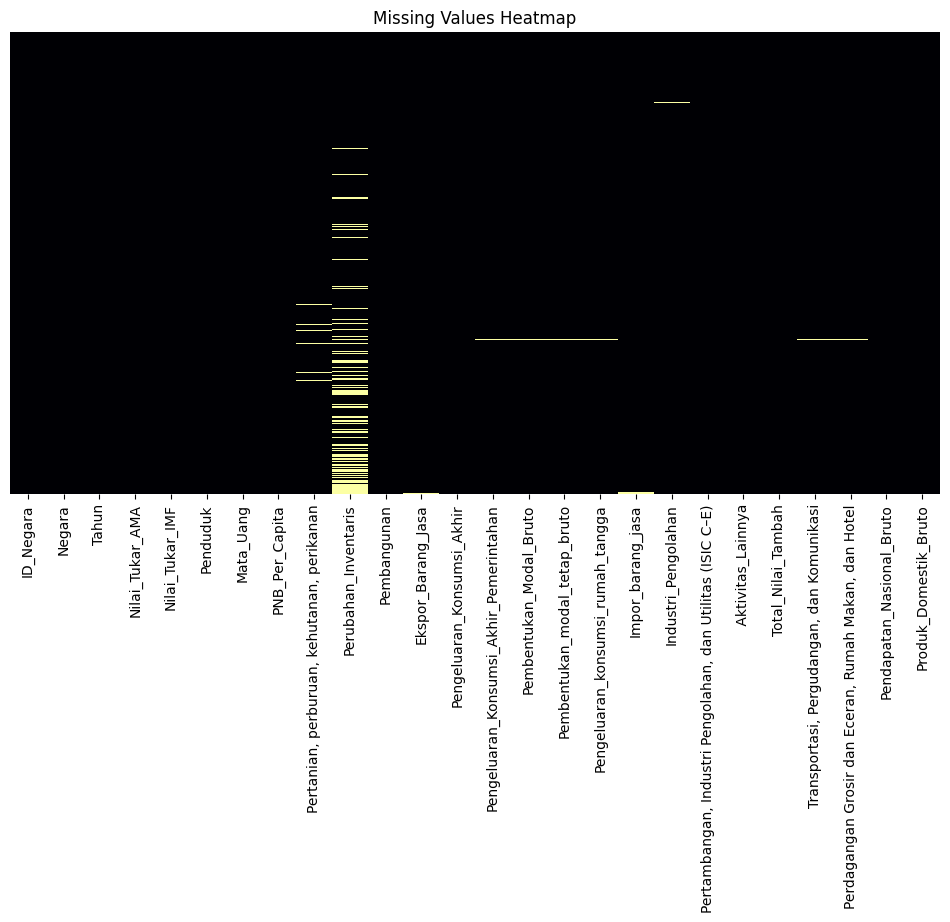

In [4]:
# Menampilkan jumlah missing values per kolom
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

# Gabungkan jumlah dan persentase missing values
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
missing_df = missing_df[missing_df['Missing Values'] > 0]

print("Missing Values Summary:")
print(missing_df.sort_values(by='Missing Values', ascending=False))

# Visualisasi heatmap missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cmap='inferno', cbar=False, yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

In [5]:
df[['Nilai_Tukar_AMA', 'Nilai_Tukar_IMF']].corr()

,Nilai_Tukar_AMA,Nilai_Tukar_IMF
Nilai_Tukar_AMA,1.000000,0.948164
Nilai_Tukar_IMF,0.948164,1.000000


karena nilai tukar AMA dan IMF sangat berkolerasi tinggi, sehingga saya memutuskan untuk drop salah satu. Jangan lupa untuk mengecek terkait distribusi data juga apakah data skewed, normal, dll.

In [6]:
df_cleaned = df.copy()
df_cleaned.drop(columns='ID_Negara', inplace=True)

# karena menurut saya negara dan mata uang memiliki fungsi yang sama untuk dataset ini. dimana mereka saling berkorelasi satu sama lain. Jadi saya hanya memilih salah satu
df_cleaned.drop(columns='Mata_Uang', inplace=True)

# karena sudah diwakilkan melalui kolom Nilai_Tukar_AMA 
df_cleaned.drop(columns='Nilai_Tukar_IMF', inplace=True)

# karena sudah diwakilkan melalui kolom Pengeluaran_Konsumsi_Akhir yang dimana merupakan konsumsi akhir total (rumah tangga + pemerintah)
df_cleaned.drop(columns='Pengeluaran_Konsumsi_Akhir_Pemerintahan', inplace=True)
df_cleaned.drop(columns='Pengeluaran_konsumsi_rumah_tangga', inplace=True)

# saya menginput missing values (imputation) berdasarkan distribusi data yang ada
df_cleaned['Perubahan_Inventaris'] = df_cleaned['Perubahan_Inventaris'].fillna(df_cleaned['Perubahan_Inventaris'].mean())
df_cleaned['Pertanian, perburuan, kehutanan, perikanan'] = df_cleaned['Pertanian, perburuan, kehutanan, perikanan'].fillna(df_cleaned['Pertanian, perburuan, kehutanan, perikanan'].median())
df_cleaned['Pembentukan_Modal_Bruto'] = df_cleaned['Pembentukan_Modal_Bruto'].fillna(df_cleaned['Pembentukan_Modal_Bruto'].median())
df_cleaned['Pembentukan_modal_tetap_bruto'] = df_cleaned['Pembentukan_modal_tetap_bruto'].fillna(df_cleaned['Pembentukan_modal_tetap_bruto'].median())
df_cleaned['Transportasi, Pergudangan, dan Komunikasi'] = df_cleaned['Transportasi, Pergudangan, dan Komunikasi'].fillna(df_cleaned['Transportasi, Pergudangan, dan Komunikasi'].median())
df_cleaned['Perdagangan Grosir dan Eceran, Rumah Makan, dan Hotel'] = df_cleaned['Perdagangan Grosir dan Eceran, Rumah Makan, dan Hotel'].fillna(df_cleaned['Perdagangan Grosir dan Eceran, Rumah Makan, dan Hotel'].median())
df_cleaned['Industri_Pengolahan'] = df_cleaned['Industri_Pengolahan'].fillna(df_cleaned['Industri_Pengolahan'].median())
df_cleaned['Impor_barang_jasa'] = df_cleaned['Impor_barang_jasa'].fillna(df_cleaned['Impor_barang_jasa'].median())
df_cleaned['Ekspor_Barang_Jasa'] = df_cleaned['Ekspor_Barang_Jasa'].fillna(df_cleaned['Ekspor_Barang_Jasa'].median())

In [7]:
df_cleaned.isna().sum()

Negara                                                        0
Tahun                                                         0
Nilai_Tukar_AMA                                               0
Penduduk                                                      0
PNB_Per_Capita                                                0
Pertanian, perburuan, kehutanan, perikanan                    0
Perubahan_Inventaris                                          0
Pembangunan                                                   0
Ekspor_Barang_Jasa                                            0
Pengeluaran_Konsumsi_Akhir                                    0
Pembentukan_Modal_Bruto                                       0
Pembentukan_modal_tetap_bruto                                 0
Impor_barang_jasa                                             0
Industri_Pengolahan                                           0
Pertambangan, Industri Pengolahan, dan Utilitas (ISIC C–E)    0
 Aktivitas_Lainnya                      

### Exploratory Data Analysis

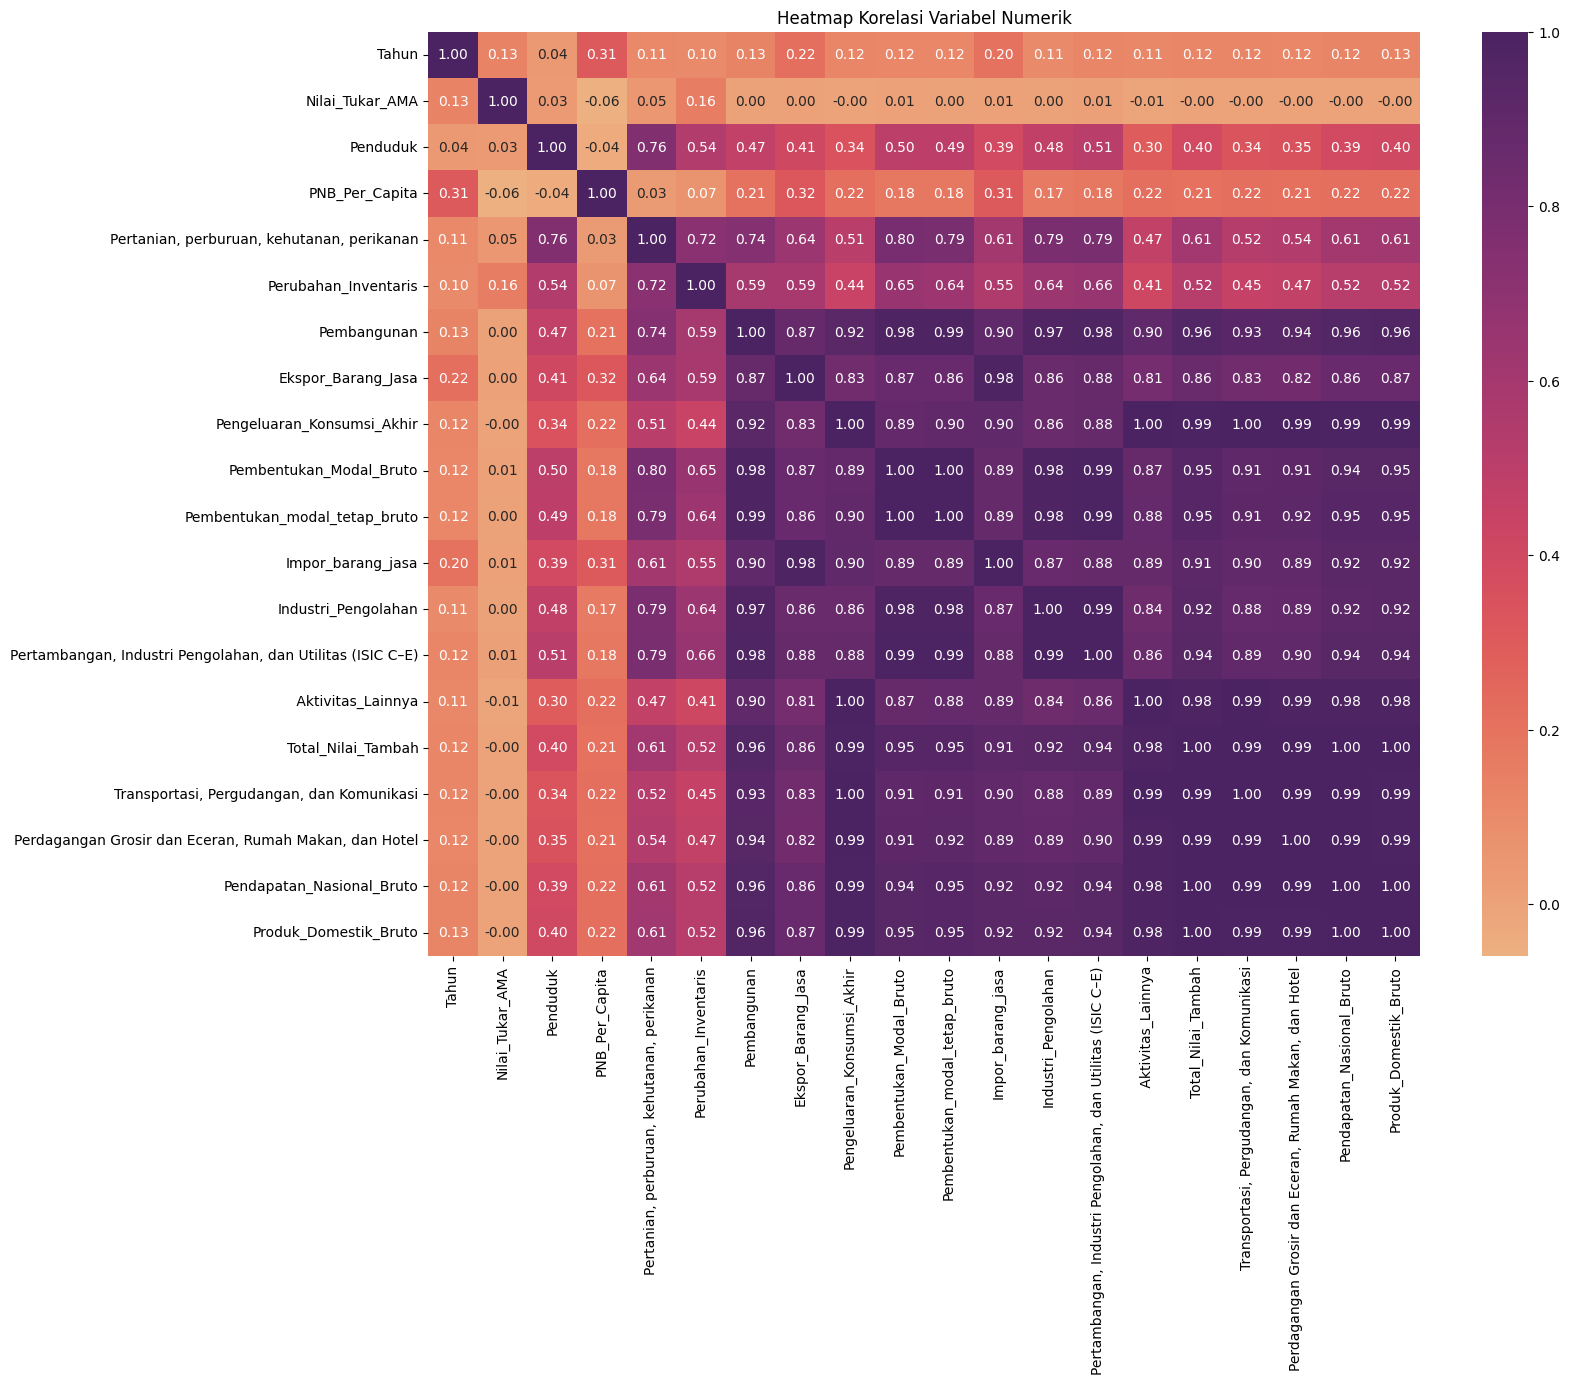

In [8]:
numerical_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(16, 12))
sns.heatmap(df_cleaned[numerical_cols].corr(), annot=True, fmt=".2f", cmap='flare')
plt.title('Heatmap Korelasi Variabel Numerik')
plt.show()

dari heatmap diatas dapat dikatakan bahwa mayoritas kolom yang bersifat numerical saling berkorelasi antar satu sama lain

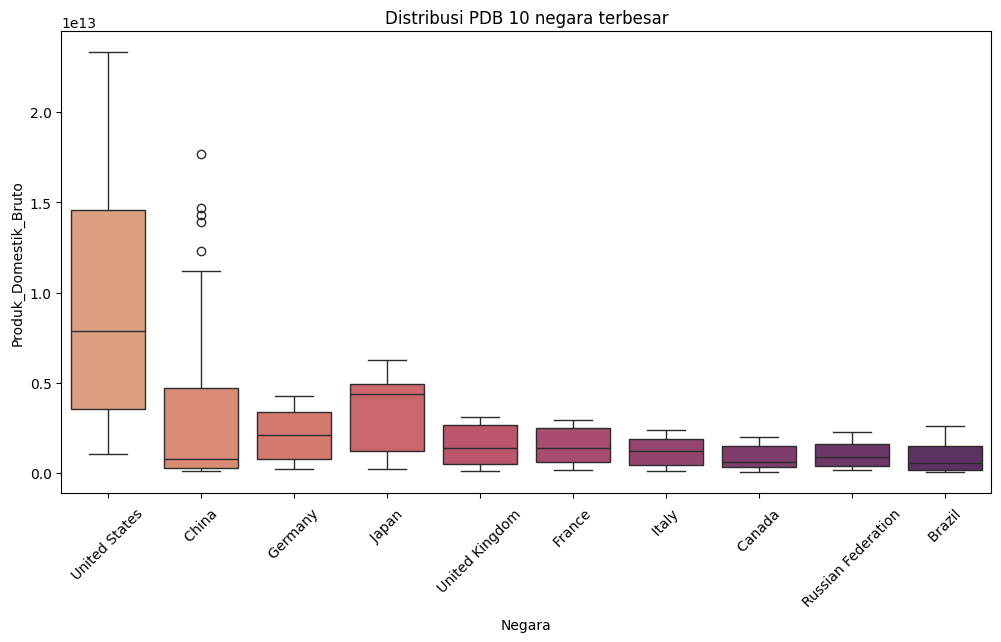

In [9]:
plt.figure(figsize=(12, 6))
top_negara = df_cleaned.groupby('Negara')['Produk_Domestik_Bruto'].mean().nlargest(10).index

sns.boxplot(data=df_cleaned[df_cleaned['Negara'].isin(top_negara)], x='Negara', y='Produk_Domestik_Bruto', hue='Negara', palette='flare')
plt.xticks(rotation=45)
plt.title('Distribusi PDB 10 negara terbesar')
plt.show()

saya juga memvisualisasikan data menggunakan histplot untuk melihat untuk melihat rata rata 10 negara dengan distribusi PDB tertinggi

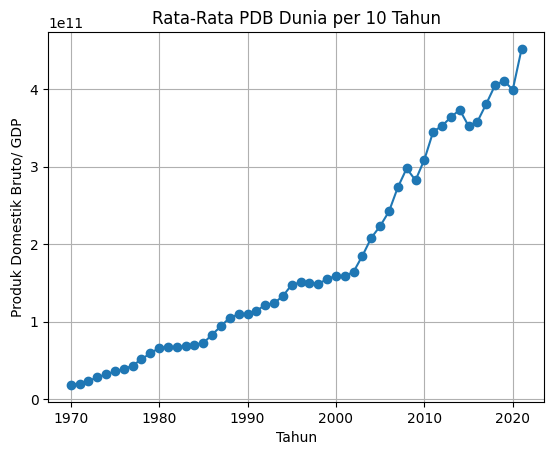

In [10]:
df_cleaned.groupby('Tahun')['Produk_Domestik_Bruto'].mean().plot(marker='o')

plt.title('Rata-Rata PDB Dunia per 10 Tahun')
plt.ylabel('Produk Domestik Bruto/ GDP')
plt.xlabel('Tahun')
plt.grid(True)
plt.show()

plot diatas menunjukkan bahwa setiap tahunnya PDB secara global cenderung selalu meningkat, walau pada bbrp tahun ada penurunan

##### Outlier Detection

In [11]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10512 entries, 0 to 10511
Data columns (total 21 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   Negara                                                      10512 non-null  object 
 1   Tahun                                                       10512 non-null  int64  
 2   Nilai_Tukar_AMA                                             10512 non-null  float64
 3   Penduduk                                                    10512 non-null  int64  
 4   PNB_Per_Capita                                              10512 non-null  int64  
 5   Pertanian, perburuan, kehutanan, perikanan                  10512 non-null  float64
 6   Perubahan_Inventaris                                        10512 non-null  float64
 7   Pembangunan                                                 10512 non-null  float64
 

karena total ada 20 kolom numerical, maka dapat dibuat plot sebesar 5x4 yang berjumlah 20 plot nantinya

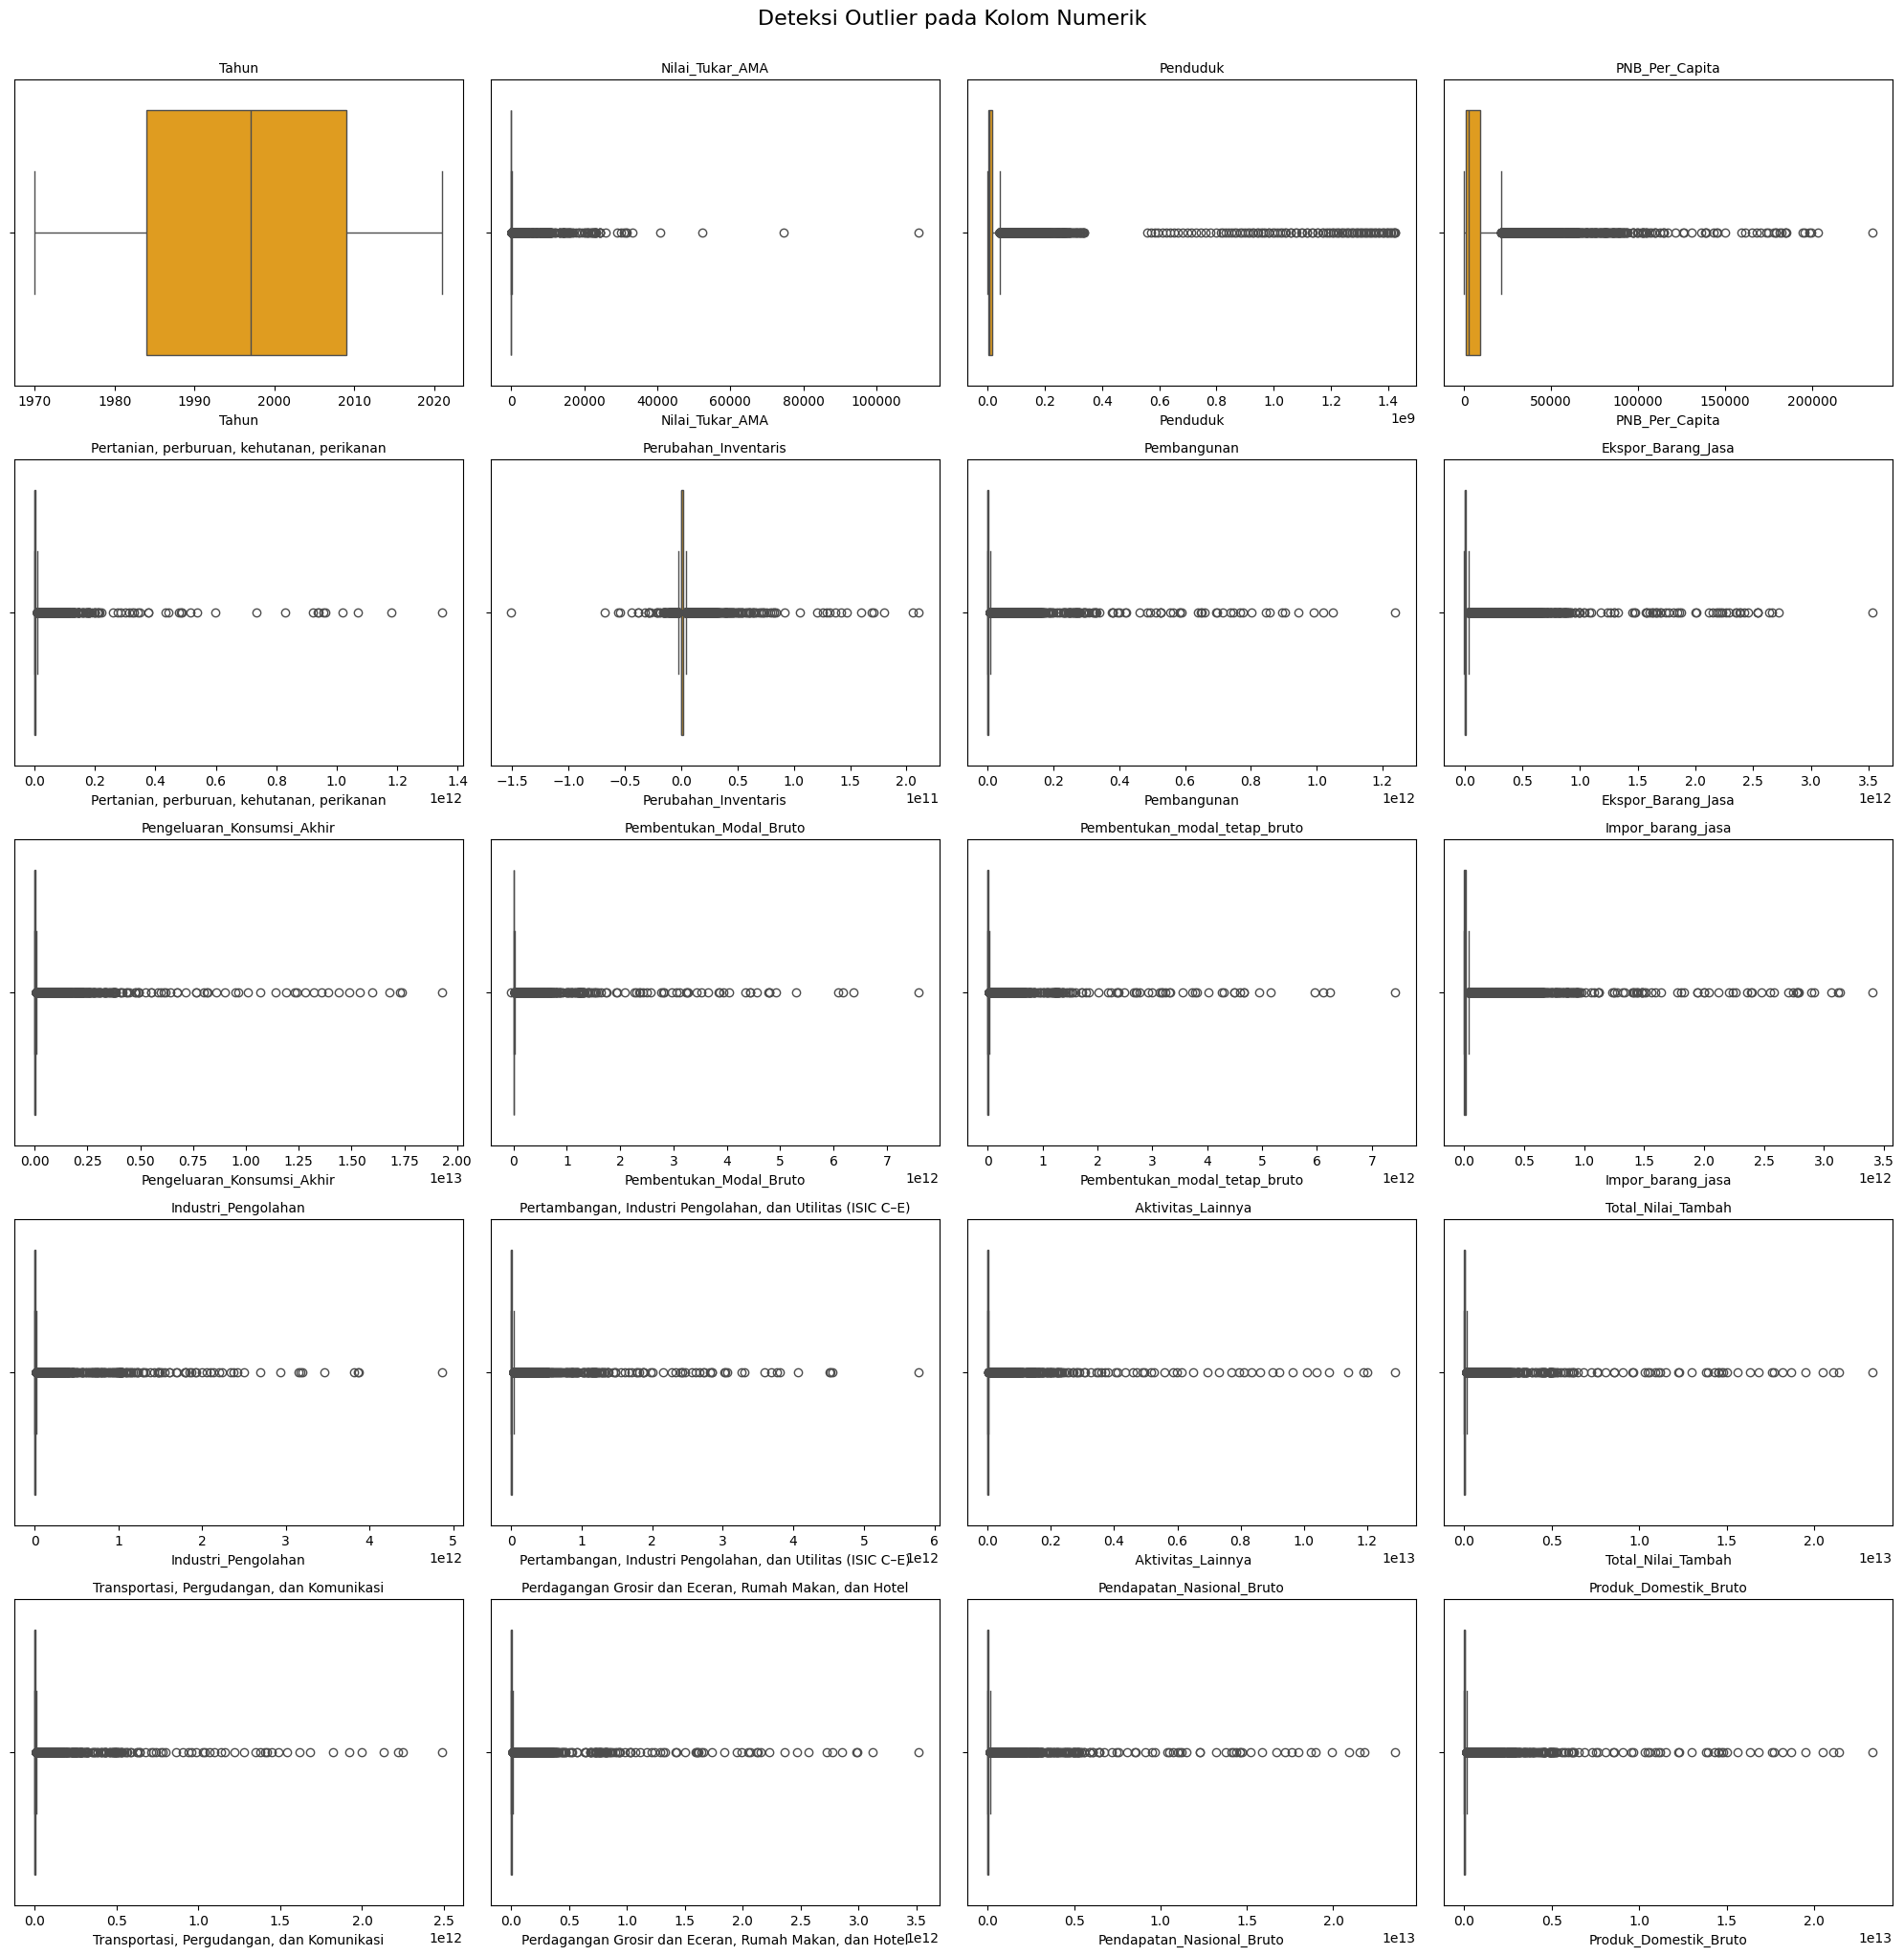

In [12]:
n_cols = 4
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

plt.figure(figsize=(n_cols * 5, n_rows * 4))  # atur ukuran figure

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df_cleaned[col], color='orange')
    plt.title(col, fontsize=10)
    plt.tight_layout()

plt.suptitle('Deteksi Outlier pada Kolom Numerik', fontsize=16, y=1.02)
plt.show()

dari visualisasi diatas terlihat bahwa ada beberapa kolom yang memiliki outlier, sehingga nantinya akan dilakukan handling outlier untuk mempermudah pengerjaan

### Feature Engineering

#### Handling Outlier

In [13]:
# Langkah 1: Tangani outlier
def handle_outliers(df_cleaned, columns):
    df_out = df_cleaned.copy()
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_out[col] = np.where(df_out[col] < lower_bound, lower_bound, df_out[col])
        df_out[col] = np.where(df_out[col] > upper_bound, upper_bound, df_out[col])
    return df_out

# Terapkan ke df_cleaned
df_handled = handle_outliers(df_cleaned, numerical_cols)

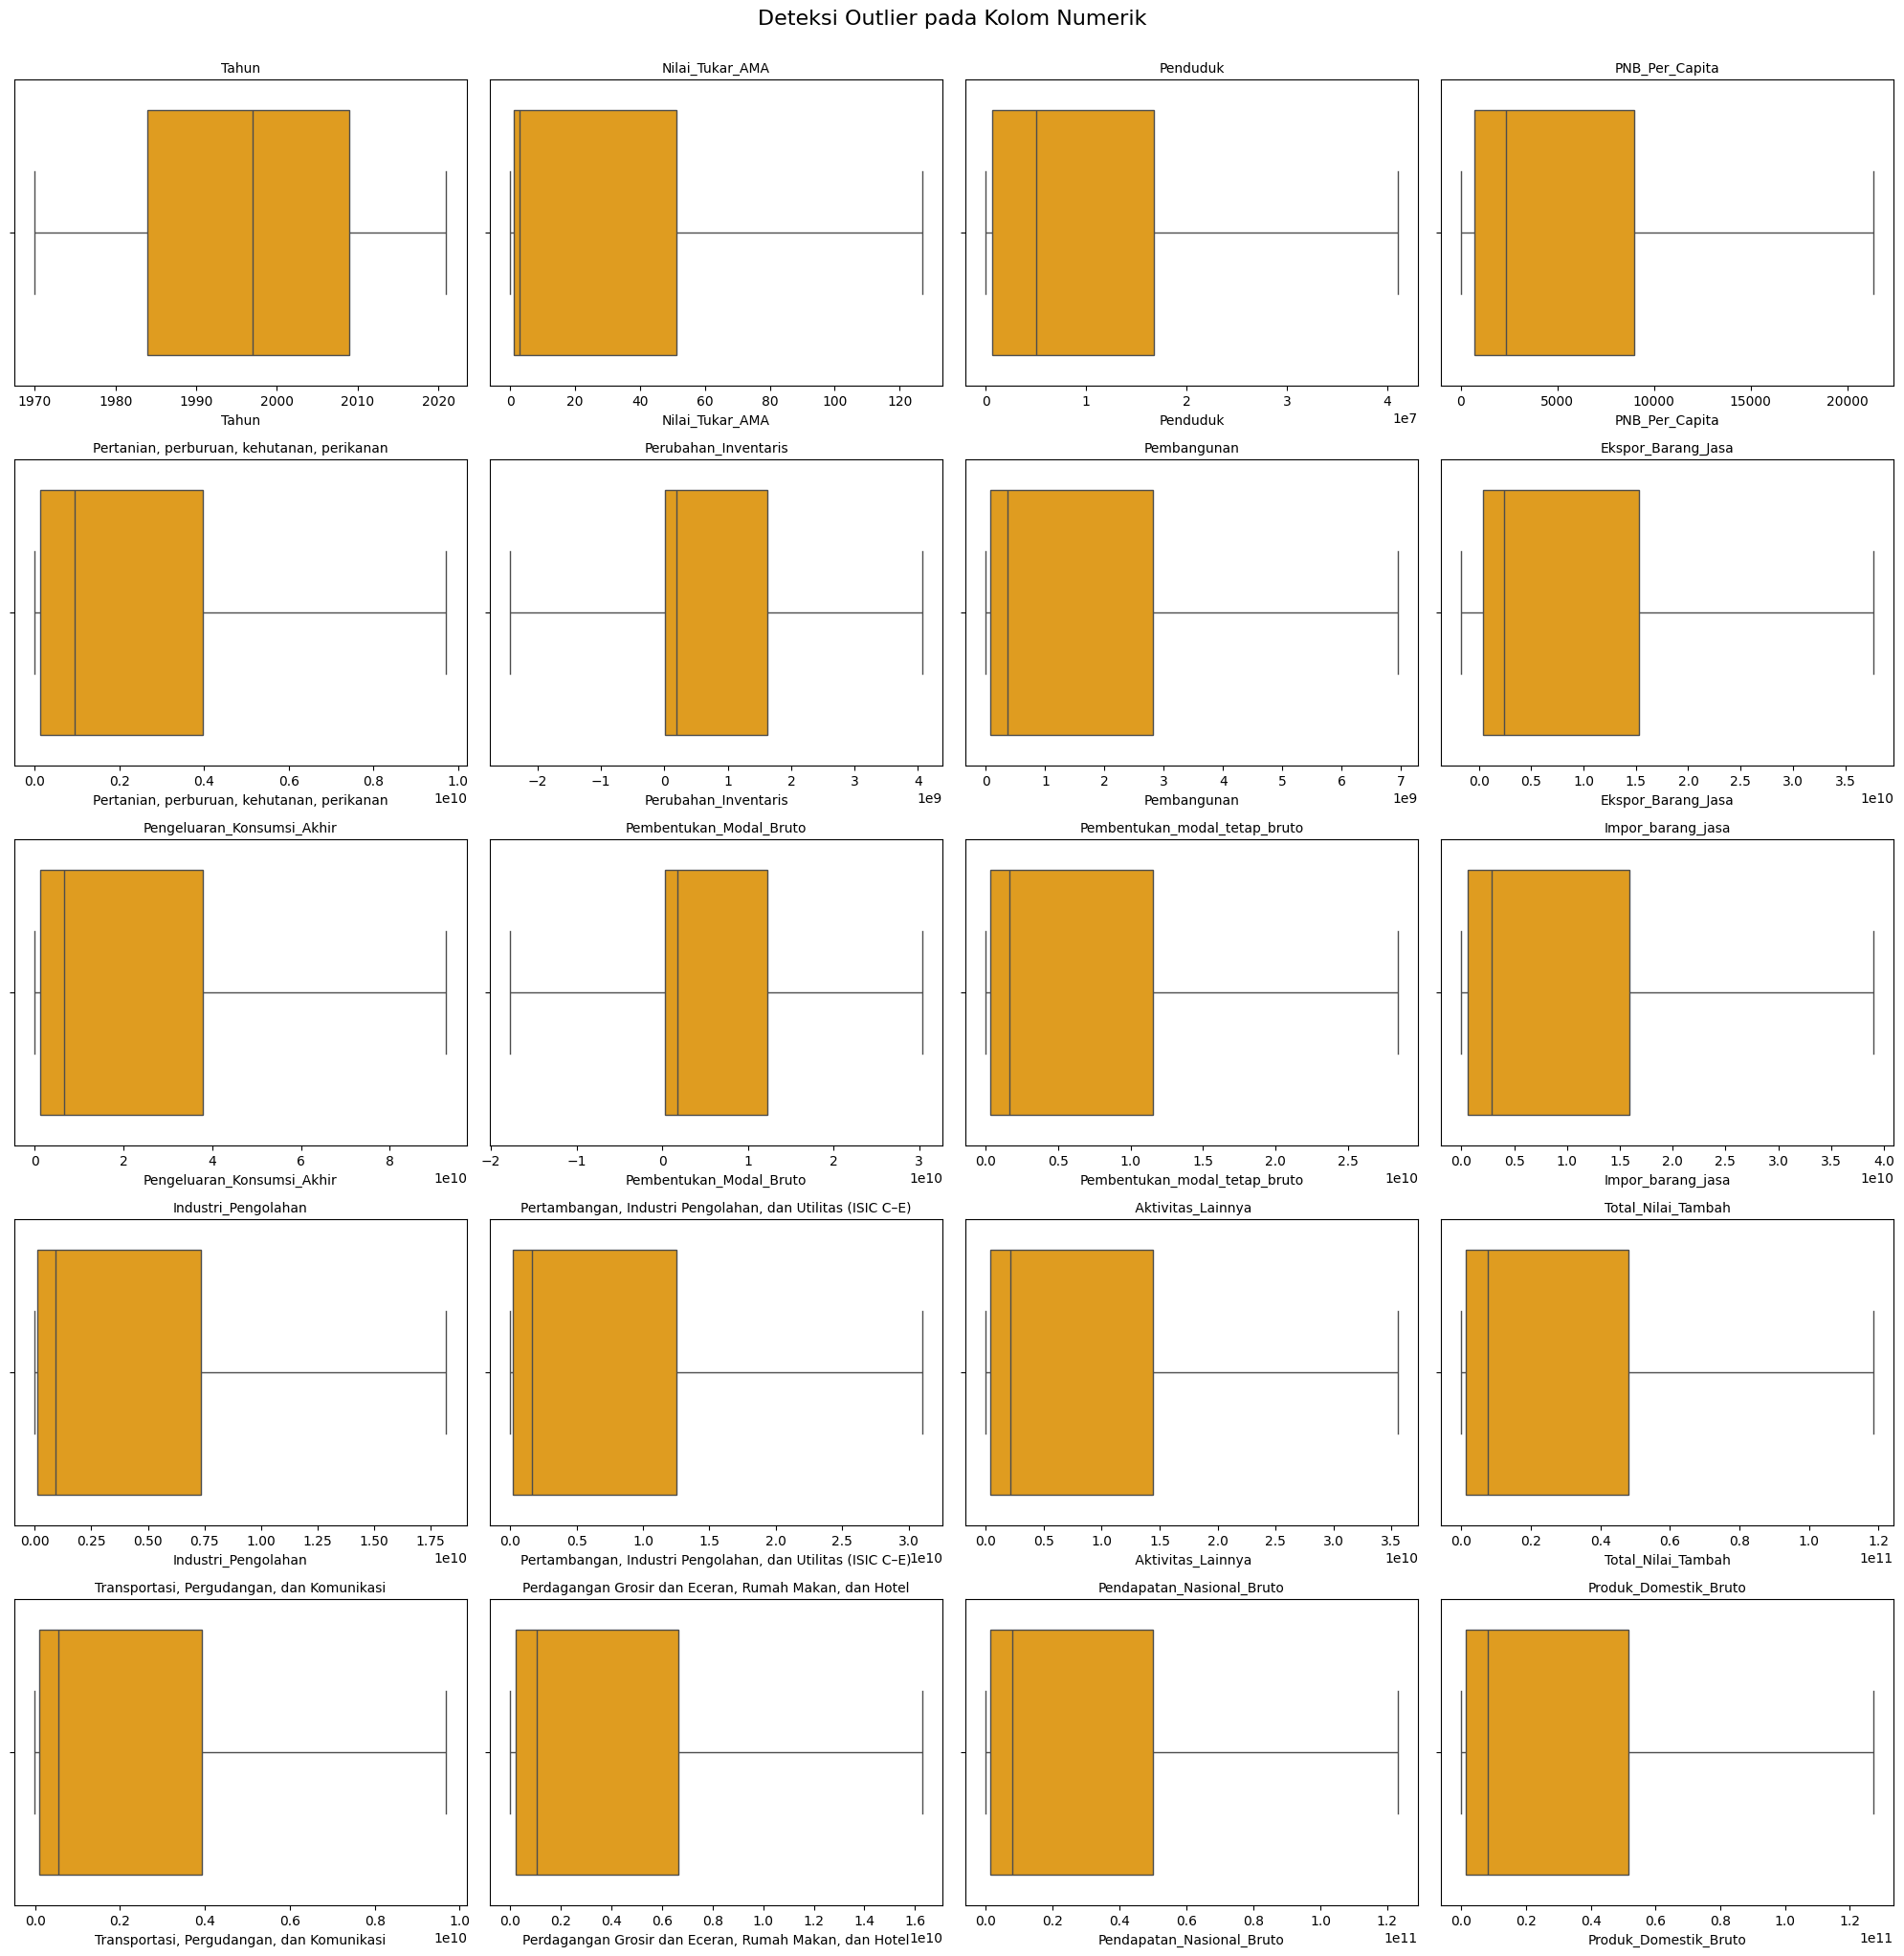

In [14]:
n_cols = 4
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

plt.figure(figsize=(n_cols * 5, n_rows * 4))  # atur ukuran figure

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df_handled[col], color='orange')
    plt.title(col, fontsize=10)
    plt.tight_layout()

plt.suptitle('Deteksi Outlier pada Kolom Numerik', fontsize=16, y=1.02)
plt.show()

#### Label Encoding untuk kolom Negara

In [15]:
le = LabelEncoder()
df_handled['Negara_encoded'] = le.fit_transform(df_handled['Negara'])

#### Normalisasi Data

In [16]:
# Langkah 2: Normalisasi dengan MinMaxScaler
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_handled[numerical_cols]), columns=numerical_cols)

# Gabungkan kembali dengan kolom 'Negara' yang sudah di-encode
df_normalisasi = pd.concat([df_handled[['Negara_encoded']], df_scaled], axis=1)

## Clustering

In [17]:
wcss = []                # Elbow
silhouette_scores = []  # Silhouette

K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_normalisasi)
    
    wcss.append(kmeans.inertia_)
    score = silhouette_score(df_normalisasi, kmeans.labels_)
    silhouette_scores.append(score)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.1

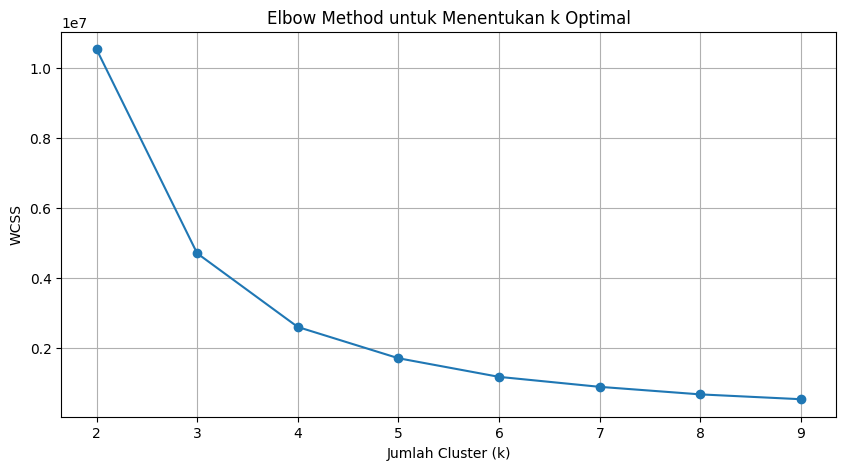

In [18]:
plt.figure(figsize=(10,5))
plt.plot(K, wcss, marker='o')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method untuk Menentukan k Optimal')
plt.grid(True)
plt.show()

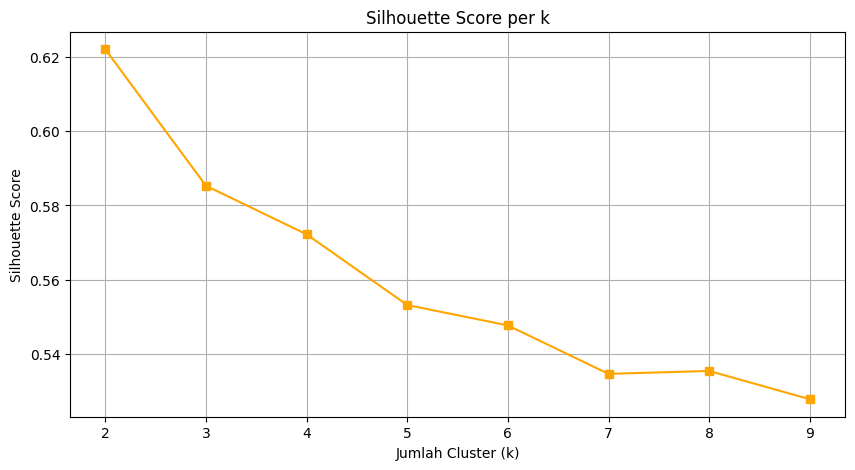

In [19]:
plt.figure(figsize=(10,5))
plt.plot(K, silhouette_scores, marker='s', color='orange')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score per k')
plt.grid(True)
plt.show()

In [20]:
# Train KMeans dengan jumlah cluster yang sudah ditentukan
kmeans = KMeans(n_clusters=3, random_state=42)
df_normalisasi['Cluster'] = kmeans.fit_predict(df_normalisasi[numerical_cols])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [25]:
# Menambahkan kolom cluster pada dataframe
df_normalisasi['Cluster'] = kmeans.labels_
df_normalisasi['Negara'] = df_cleaned['Negara']

for cluster_num in df_normalisasi['Cluster'].unique():
    print(f"Cluster {cluster_num}:")
    cluster_countries = df_normalisasi[df_normalisasi['Cluster'] == cluster_num]['Negara'].drop_duplicates().tolist()
    print(cluster_countries)
    print("\n")

Cluster 2:
[' United States ', ' China ', ' Germany ', ' Japan ', ' United Kingdom ', ' France ', ' India ', ' Netherlands ', ' China, Hong Kong SAR ', ' Republic of Korea ', ' Italy ', ' Canada ', ' Singapore ', ' Mexico ', ' Belgium ', ' Ireland ', ' Spain ', ' Russian Federation ', ' Switzerland ', ' Poland ', ' United Arab Emirates ', ' Brazil ', ' Australia ', ' Viet Nam ', ' Thailand ', ' Türkiye ', ' Austria ', ' Sweden ', ' Saudi Arabia ', ' Indonesia ', ' Malaysia ', ' Venezuela (Bolivarian Republic of) ', ' Denmark ', ' Czechia ', ' Philippines ', ' Hungary ', ' Iran (Islamic Republic of) ', ' Norway ', ' Romania ', ' Greece ', ' South Africa ', ' Israel ', ' Finland ', ' Portugal ', ' Slovakia ', ' Chile ', ' Ukraine ', ' Nigeria ', ' Argentina ', ' Egypt ', ' Colombia ', ' Iraq ', ' Bangladesh ', ' Algeria ', ' Qatar ', ' New Zealand ', ' Kazakhstan ', ' Kuwait ', ' Pakistan ', ' Puerto Rico ', ' Morocco ', ' Peru ', ' Angola ', ' Bulgaria ', ' Belarus ', ' Oman ', ' Ecuado

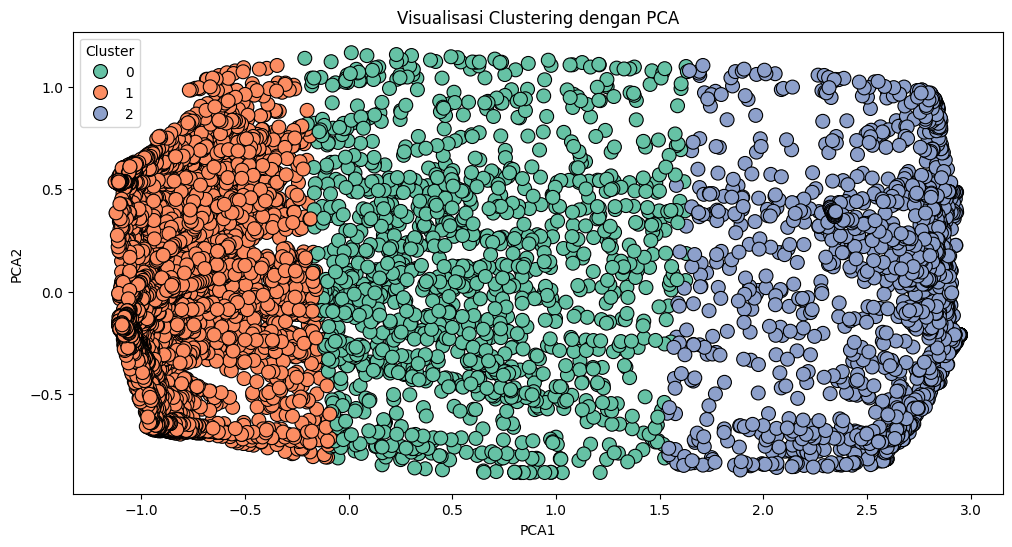

In [22]:
# Reduksi dimensi ke 2D untuk visualisasi
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_normalisasi[numerical_cols])

# Menambahkan PCA ke dataframe
df_normalisasi['PCA1'] = df_pca[:, 0]
df_normalisasi['PCA2'] = df_pca[:, 1]

# Visualisasi dengan seaborn
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_normalisasi, x='PCA1', y='PCA2', hue='Cluster', palette='Set2', s=100, edgecolor='black')
plt.title('Visualisasi Clustering dengan PCA')
plt.show()

### Evaluasi hasil clustering

In [23]:
sil_score = silhouette_score(df_normalisasi[numerical_cols], kmeans.labels_)
print(f'Silhouette Score untuk 3 cluster: {sil_score}')

Silhouette Score untuk 3 cluster: 0.46163400829496587
